<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [10]:
#!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

zsh:1: command not found: wget


In [12]:
!pip install wget

In [22]:
import requests

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite"
filename = "survey-results-public.sqlite"

response = requests.get(url)

with open(filename, "wb") as f:
    f.write(response.content)

print("Downloaded:", filename)

Downloaded: survey-results-public.sqlite


#### 2. Connect to the Database


**Install the needed libraries**


In [14]:
!pip install pandas

In [15]:
!pip install matplotlib

In [23]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [24]:
QUERY = "SELECT COUNT(*) FROM main"
df_count = pd.read_sql_query(QUERY, conn)
print(df_count)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [25]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [26]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [27]:
df = pd.read_sql_query("SELECT * FROM main", conn)

df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,None,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,None,None,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",None,Apples,None,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",None,Apples,None,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [28]:
# your code goes here

df['CompTotal'].describe()

count     3.374000e+04
mean     2.963841e+145
std      5.444117e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.500000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64

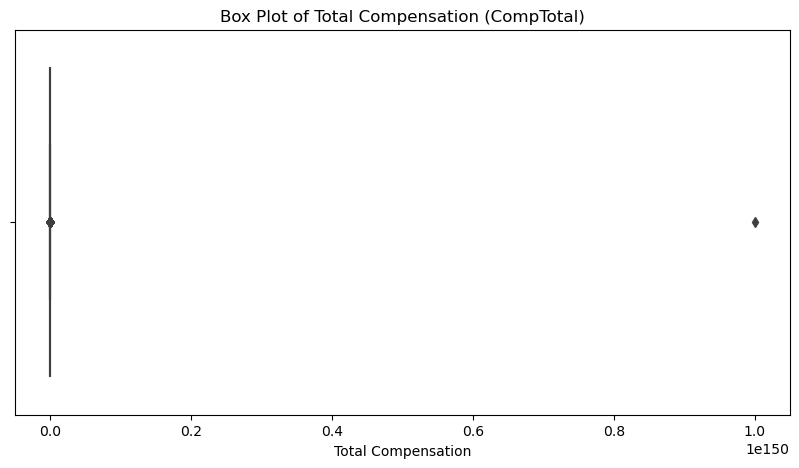

In [29]:
# BOXPLOT

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(x=df['CompTotal'])

plt.title('Box Plot of Total Compensation (CompTotal)')
plt.xlabel('Total Compensation')

plt.show()

In [30]:
## Use clean data

df_comp = df[['CompTotal']].dropna()

Q1 = df_comp['CompTotal'].quantile(0.25)
Q3 = df_comp['CompTotal'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df_comp[
    (df_comp['CompTotal'] >= lower) &
    (df_comp['CompTotal'] <= upper)
]

df_clean.describe(include="all")

,CompTotal
count,27864.000000
mean,117182.605369
std,99970.300622
min,0.000000
25%,50000.000000
50%,88000.000000
75%,150000.000000
max,535000.000000


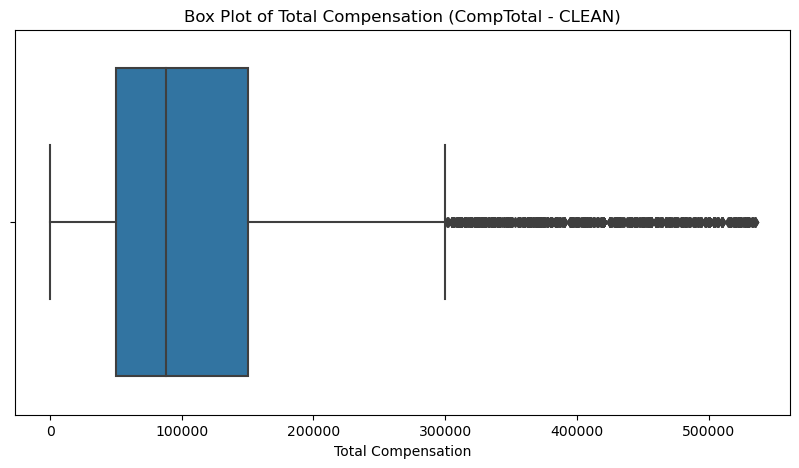

In [31]:
# BOXPLOT WITH CLEAN DATA

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(x=df_clean['CompTotal'])

plt.title('Box Plot of Total Compensation (CompTotal - CLEAN)')
plt.xlabel('Total Compensation')

plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [32]:
# Transforming Age as Age_num

age_map = {
    'Under 18 years old': 17.0,
    '18-24 years old': 21.0,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70.0
}

df['Age_num'] = df['Age'].map(age_map)

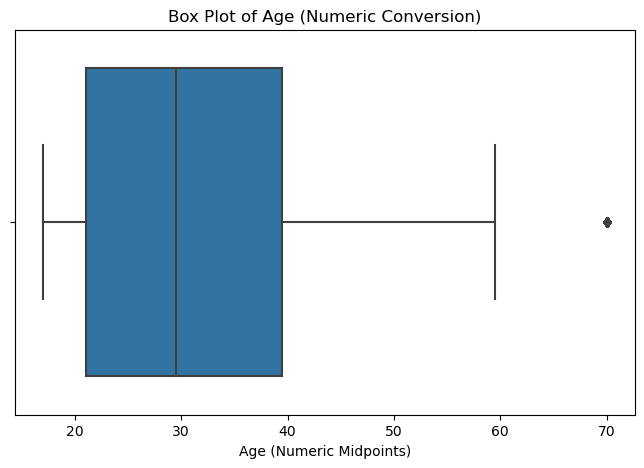

In [33]:
## Boxplot of transformed age column

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Age_num'])

plt.title('Box Plot of Age (Numeric Conversion)')
plt.xlabel('Age (Numeric Midpoints)')

plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [40]:
# Clean the CompTotal col in the df, as a new col df['CompTotal_clean']

comp = df['CompTotal']

Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['CompTotal_clean'] = df['CompTotal'].where(
    (df['CompTotal'] >= lower) &
    (df['CompTotal'] <= upper)
)

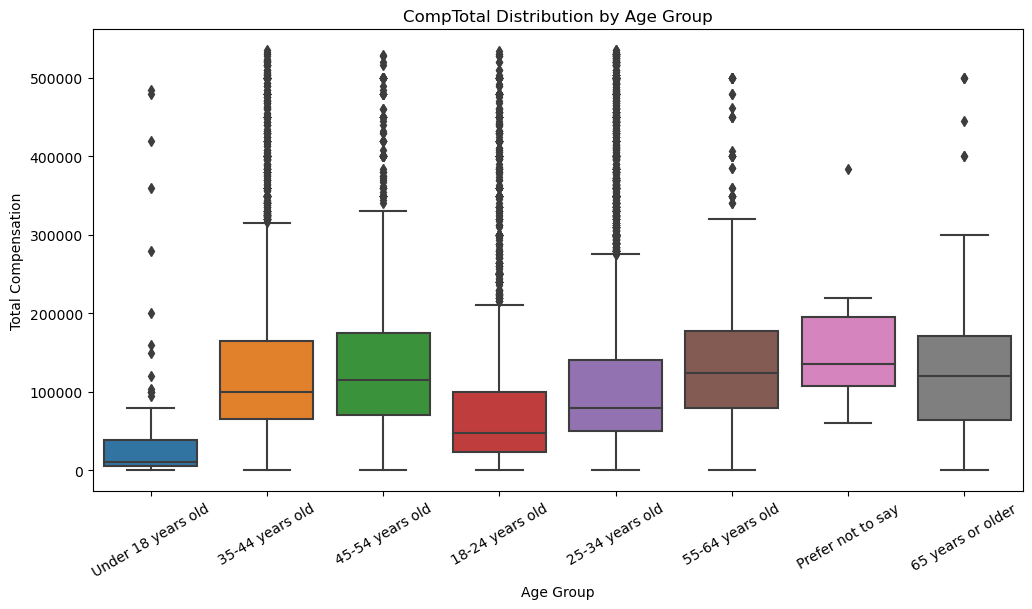

In [41]:
# Clean boxplot of CompTotal Distribution by Age Group

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Age',
    y='CompTotal_clean'
)

plt.title('CompTotal Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Compensation')

plt.xticks(rotation=30)

plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [42]:
# Inspection first

print("Missing CompTotal:", df['CompTotal'].isna().sum())
print("CompTotal summary:\n", df['CompTotal'].describe())

print("\nMissing JobSatPoints_6:", df['JobSatPoints_6'].isna().sum())
print("\nJobSatPoints_6 value counts:\n", df['JobSatPoints_6'].value_counts(dropna=False).head(10))

print("\nJobSatPoints_6 dtype:", df['JobSatPoints_6'].dtype)


Missing CompTotal: 31697
CompTotal summary:
 count     3.374000e+04
mean     2.963841e+145
std      5.444117e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.500000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64

Missing JobSatPoints_6: 35987

JobSatPoints_6 value counts:
 NaN      35987
0.0       7912
20.0      4352
10.0      3328
30.0      2482
15.0      1466
25.0      1339
50.0      1237
40.0      1068
100.0     1020
Name: JobSatPoints_6, dtype: int64

JobSatPoints_6 dtype: float64


In [45]:
# Bins or grouping in broader categories Job Satisfaction 6

bins = [-1, 0, 20, 40, 60, 100]

labels = [
    'Very Low (0)',
    'Low (1–20)',
    'Moderate (21–40)',
    'High (41–60)',
    'Very High (61–100)'
]

df['JobSat_group'] = pd.cut(
    df['JobSatPoints_6'],
    bins=bins,
    labels=labels
)

In [46]:
# cleaning data first

df_js = df[['CompTotal_clean', 'JobSat_group']].dropna()

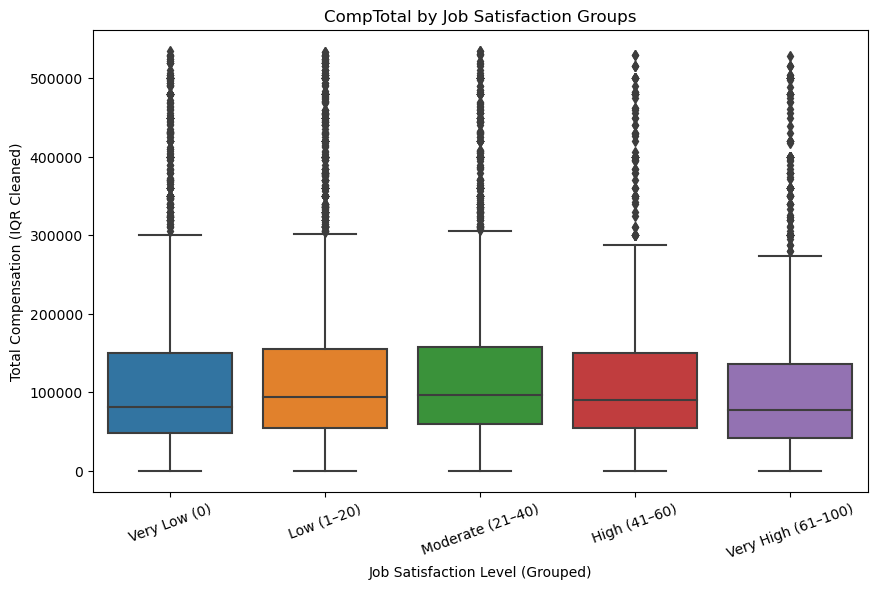

In [47]:
# Boxplot 

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_js,
    x='JobSat_group',
    y='CompTotal_clean'
)

plt.title('CompTotal by Job Satisfaction Groups')
plt.xlabel('Job Satisfaction Level (Grouped)')
plt.ylabel('Total Compensation (IQR Cleaned)')

plt.xticks(rotation=20)

plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [49]:
# Inspect variables

print("Missing ConvertedCompYearly:", df['ConvertedCompYearly'].isna().sum())

print("\nSummary:\n", df['ConvertedCompYearly'].describe())

print("\nDeveloper type distribution:\n", df['DevType'].value_counts().head(10))

print("\nDeveloper unique type distribution:\n", df['DevType'].nunique())

Missing ConvertedCompYearly: 42002

Summary:
 count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

Developer type distribution:
 Developer, full-stack                            18260
Developer, back-end                               9928
Student                                           5102
Developer, front-end                              3349
Developer, desktop or enterprise applications     2493
Other (please specify):                           2458
Developer, mobile                                 2021
Developer, embedded applications or devices       1623
Engineering manager                               1275
Academic researcher                               1238
Name: DevType, dtype: int64

Developer unique type distribution:
 34


In [50]:
# Deal with outliers in converted comp yearly

comp = df['ConvertedCompYearly']

Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['ConvertedCompYearly_clean'] = df['ConvertedCompYearly'].where(
    (df['ConvertedCompYearly'] >= lower) &
    (df['ConvertedCompYearly'] <= upper)
)

In [55]:
# Select top 5 developer types

top5_roles = df['DevType'].value_counts().head(5).index

df_top5 = df[df['DevType'].isin(top5_roles)]
df_top5.shape

(39132, 118)

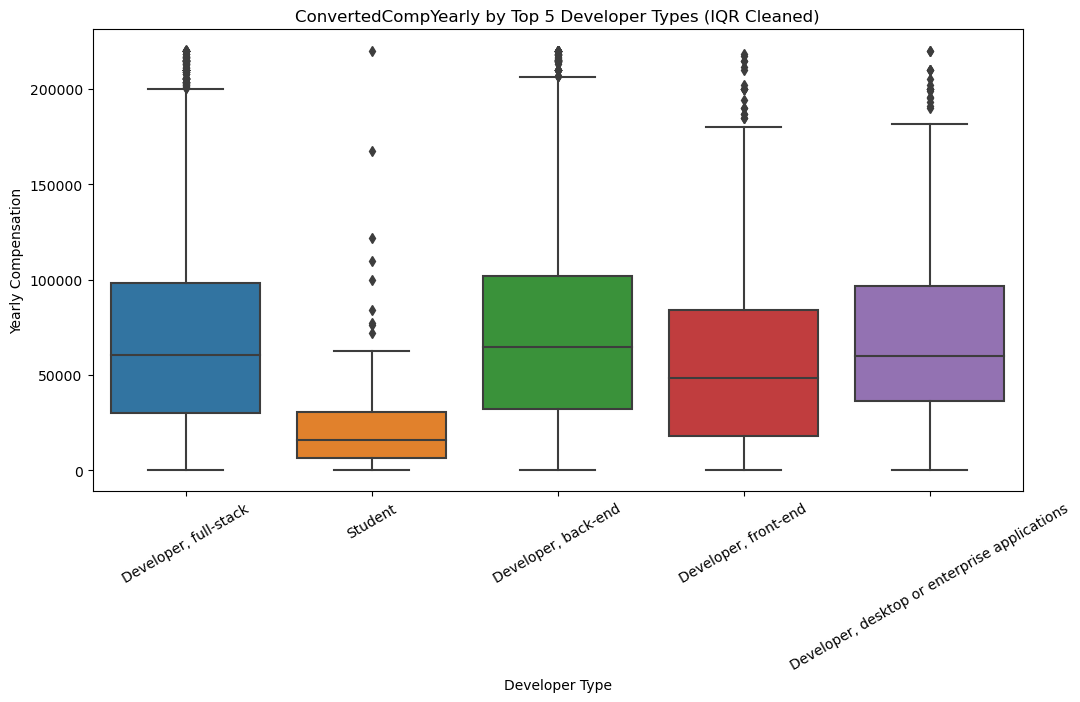

In [56]:
# Boxplot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_top5,
    x='DevType',
    y='ConvertedCompYearly_clean'
)

plt.title('ConvertedCompYearly by Top 5 Developer Types (IQR Cleaned)')
plt.xlabel('Developer Type')
plt.ylabel('Yearly Compensation')

plt.xticks(rotation=30)

plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [58]:
# Use the already clean column for  CompTotal (free of outliers); and select the 5 countries with more respondents

top5_countries = df['Country'].value_counts().head(5).index

df_top5 = df[df['Country'].isin(top5_countries)]
df_top5.shape

(26169, 118)

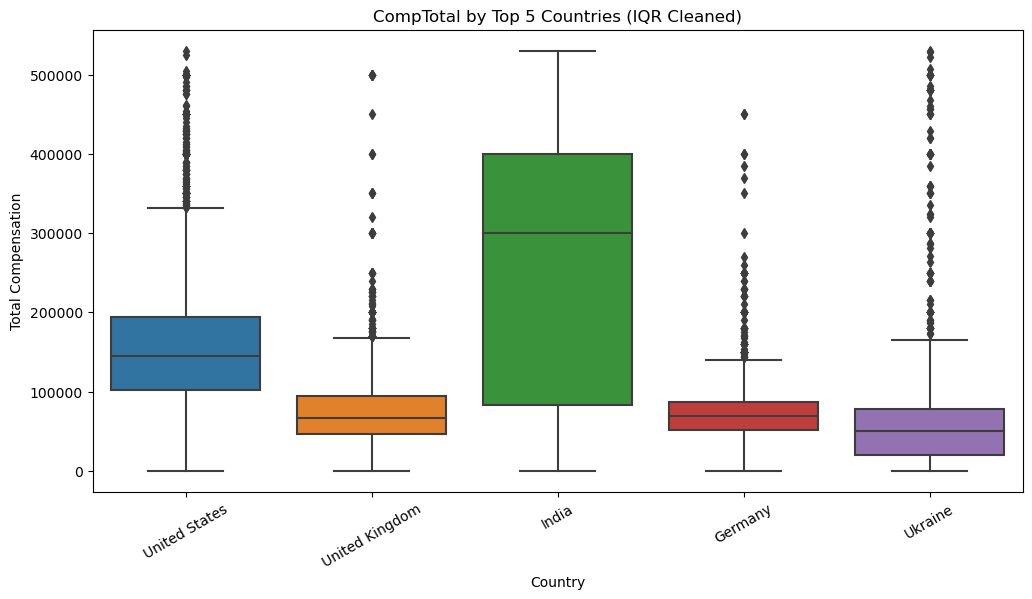

In [60]:
# Box plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

ax = sns.boxplot(
    data=df_top5,
    x='Country',
    y='CompTotal_clean'
)

# 🔹 shorten x-axis labels (first 2 words only)
new_labels = [
    " ".join(str(label).split()[:2]) for label in df_top5['Country'].unique()
]

ax.set_xticklabels(new_labels, rotation=30)

plt.title('CompTotal by Top 5 Countries (IQR Cleaned)')
plt.xlabel('Country')
plt.ylabel('Total Compensation')

plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [61]:
# your code goes here

print("Missing Employment:", df['Employment'].isna().sum())

print("\nEmployment distribution:\n", df['Employment'].value_counts().head(10))

print("\nUnique Employment:\n", df['Employment'].unique())

print("\nCompTotal clean summary:\n", df['CompTotal_clean'].describe())


Missing Employment: 0

Employment distribution:
 Employed, full-time                                                         39041
Independent contractor, freelancer, or self-employed                         4846
Student, full-time                                                           4709
Employed, full-time;Independent contractor, freelancer, or self-employed     3557
Not employed, but looking for work                                           2341
Employed, part-time                                                          1266
Student, full-time;Employed, part-time                                       1115
Employed, full-time;Student, full-time                                        897
Employed, full-time;Student, part-time                                        839
Student, full-time;Not employed, but looking for work                         686
Name: Employment, dtype: int64

Unique Employment:
 ['Employed, full-time' 'Student, full-time'
 'Student, full-time;Not employed, 

In [62]:
# Grouping Employment in broader categories

def simplify_employment(x):
    if pd.isna(x):
        return 'Other'
    
    first = x.split(';')[0]
    
    if first.startswith('Employed'):
        return 'Employed'
    elif first.startswith('Independent'):
        return 'Independent'
    elif first.startswith('Student'):
        return 'Student'
    elif 'but looking for work' in first:
        return 'Unemployed - Looking'
    elif 'and not looking for work' in first:
        return 'Unemployed - Not Looking'
    elif first.startswith('Retired'):
        return 'Retired'
    else:
        return 'Other'

df['Employment_Group'] = df['Employment'].apply(simplify_employment)

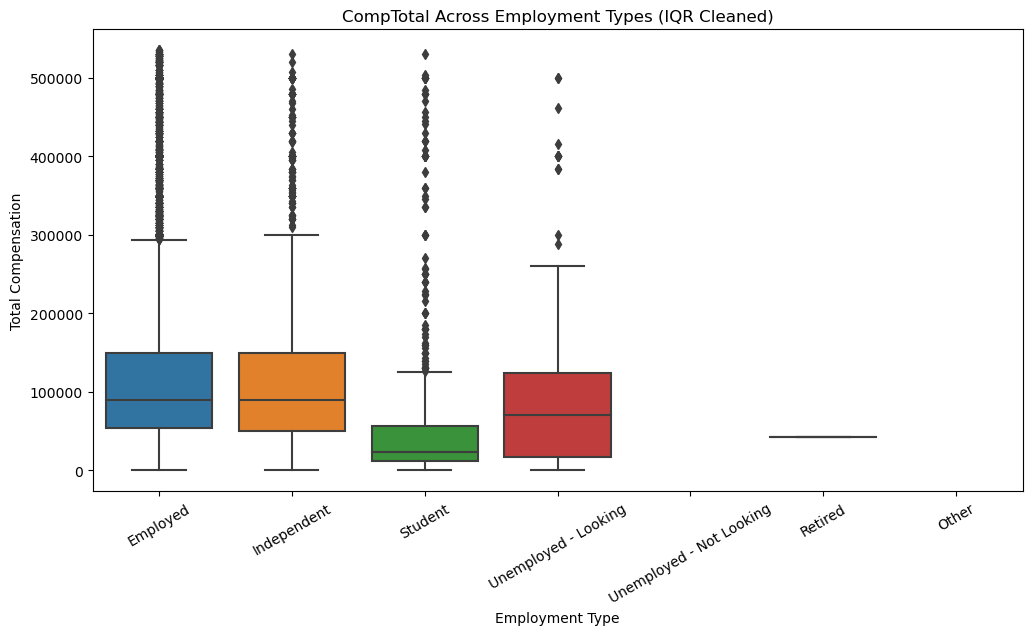

In [63]:
# BOX PLOT

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

order = [
    'Employed',
    'Independent',
    'Student',
    'Unemployed - Looking',
    'Unemployed - Not Looking',
    'Retired',
    'Other'
]

sns.boxplot(
    data=df,
    x='Employment_Group',
    y='CompTotal_clean',
    order=order
)

plt.title('CompTotal Across Employment Types (IQR Cleaned)')
plt.xlabel('Employment Type')
plt.ylabel('Total Compensation')

plt.xticks(rotation=30)

plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [67]:
df['YearsCodePro'].value_counts()

2                     4168
3                     4093
5                     3526
10                    3251
4                     3215
Less than 1 year      2856
6                     2843
1                     2639
8                     2549
7                     2517
12                    1777
15                    1635
20                    1549
9                     1493
11                    1312
13                    1127
14                    1082
25                     998
16                     946
18                     867
17                     814
30                     689
24                     632
19                     516
22                     492
23                     448
26                     426
21                     380
27                     380
28                     342
35                     285
29                     196
40                     194
32                     194
34                     169
38                     134
33                     132
3

In [69]:
# Transform data yearscode pro

def convert_experience(x):
    if pd.isna(x):   # handles None and NaN
        return None
    
    if x == "Less than 1 year":
        return 0.5
    elif x == "More than 50 years":
        return 50
    else:
        return float(x)

df['YearsCodePro_num'] = df['YearsCodePro'].apply(convert_experience)


In [71]:
df['YearsCodePro_num'].describe()

count    51610.000000
mean        10.211044
std          9.075136
min          0.500000
25%          3.000000
50%          7.000000
75%         15.000000
max         50.000000
Name: YearsCodePro_num, dtype: float64

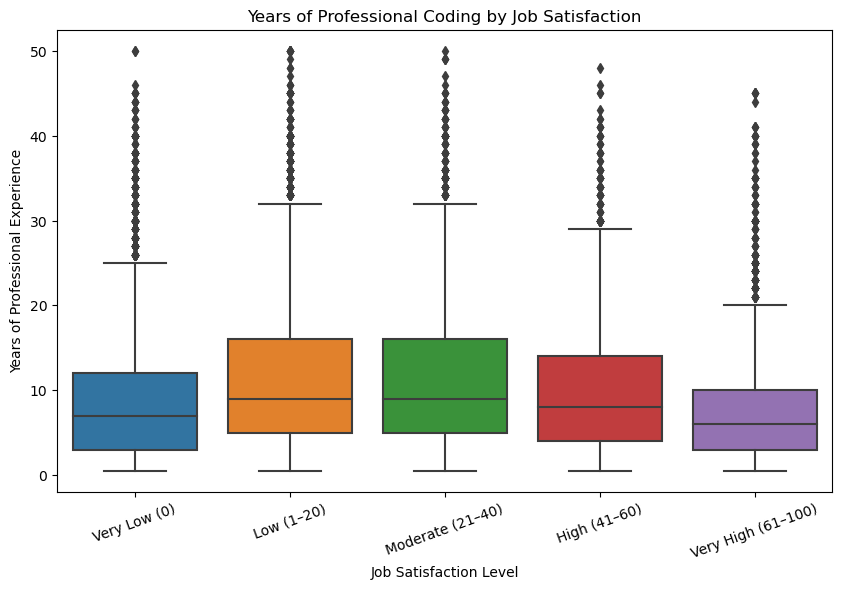

In [72]:
# Box plot of df['JobSatPoints_6'] as "JobSat_group" & YearsCodePro_num'

import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df[['YearsCodePro_num', 'JobSat_group']].dropna()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_plot,
    x='JobSat_group',
    y='YearsCodePro_num',
    order=[
        'Very Low (0)',
        'Low (1–20)',
        'Moderate (21–40)',
        'High (41–60)',
        'Very High (61–100)'
    ]
)

plt.title('Years of Professional Coding by Job Satisfaction')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Years of Professional Experience')

plt.xticks(rotation=20)

plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
